# SRP v4 — Step 5: Per-Feature Embeddings, on Four Datasets

### What the diagnostics said to fix

Notebook 04 ran Grinsztajn et al.'s three tests. One gave a clean verdict: **our models ignore the feature axes.**
Randomly rotating the features costs XGBoost up to 17 accuracy points and costs us nothing — and once the axes are
scrambled, our models actually *beat* XGBoost on Poker and HIGGS. So the tree advantage lives in the axes, and our
architecture cannot see them, because every expert's first layer immediately mixes its columns together.

### The change

A stage **before any mixing**, where each feature is encoded by its own parameters ([`embeddings.py`](./embeddings.py)):

| Mode | What it does | Purpose |
|---|---|---|
| `none` | identity | today's v4, unchanged |
| `linear` | per-feature `Linear(1→d)` + ReLU | **control**: per-feature, but still smooth |
| `periodic` | per-feature `[sin, cos]` at learnable frequencies → `Linear` → ReLU ("PLR") | per-feature **and** able to change sharply within one feature |

The control matters: if `linear` captures most of the gain, what helped is treating features separately; if only
`periodic` helps, the gain comes from representing sharp, threshold-like behaviour, which is the other thing trees do.

### What this notebook answers

1. **Do embeddings help, on more than one dataset?** Four datasets, since housing alone can't settle anything.
2. **Does the gain need the periodic part**, or is per-feature processing enough?
3. **Did the fix actually work mechanically?** We re-run the rotation test: if the model now uses the axes, rotating
   the features should finally **hurt** it. That is the direct check that we fixed the diagnosed problem, not just
   moved a number.

Protocol as before: train/val/test splits, early stopping on validation, test set only for reporting, 3 seeds,
same training contract for every arm. XGBoost and PlainMLP are reference lines, not arms.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd(); sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from joblib import Parallel, delayed

from datasets import make_task
from diagnostics import rotate_features
from embeddings import EmbeddingConfig
from tuning import tune_xgb, make_xgb, xgb_metrics

DATASETS = ["california", "covertype", "poker", "higgs"]
N_TRAIN, N_VAL, N_TEST = 10_000, 5_000, 20_000      # for the three large datasets
SEEDS = (0, 1, 2)
AGGREGATORS = ["meanpool_wide", "causal"]
MODES = ["none", "linear", "periodic"]
XGB_TRIALS = 25

EMB_KW  = dict(d_embedding=8, n_frequencies=16, sigma=0.1)
ENS_KW  = dict(num_learners=16, hidden_dim=16, embed_dim=32, depth=1, dropout=0.1, feature_frac=0.7)
ATT_KW  = dict(embed_dim=32, num_heads=4, attn_depth=2, ff_mult=4, dropout=0.1, need_weights=False)
TRAIN_KW = dict(epochs=200, lr=1e-3, batch_size=256, weight_decay=1e-4, patience=20)

THREADS_PER_JOB = 2
N_JOBS = max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB))
DS_LABEL = {"california": "California Housing", "covertype": "Covertype",
            "poker": "Poker Hand", "higgs": "HIGGS"}
MODE_LABEL = {"none": "none (current v4)", "linear": "linear", "periodic": "periodic (PLR)"}
AGG_LABEL = {"meanpool_wide": "Mean-pool", "causal": "Causal attn"}
COLOR = {"none": "#b9b0ee", "linear": "#1fa899", "periodic": "#9c1c47",
         "PlainMLP": "#4c8dff", "XGBoost": "#ff8a3d"}

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
LOG_PATH = os.path.join(RUN_DIR, "06_progress.log")
if os.path.exists(LOG_PATH): os.remove(LOG_PATH)
def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")
def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

sns.set_theme(style="whitegrid", context="notebook")
log(f"{N_JOBS} workers x {THREADS_PER_JOB} threads | datasets {DATASETS}")

8 workers x 2 threads | datasets ['california', 'covertype', 'poker', 'higgs']


## 1. Data — four datasets, three of them new

In [2]:
TASKS, ROTATED = {}, {}
for name in DATASETS:
    t = make_task(name) if name == "california" else make_task(name, N_TRAIN, N_VAL, N_TEST, seed=0)
    TASKS[name] = t
    ROTATED[name] = rotate_features(t, seed=1)
METRIC = {n: ("r2" if TASKS[n].task == "regression" else "acc") for n in DATASETS}
show(pd.DataFrame([{"dataset": DS_LABEL[n], "task": TASKS[n].task, "metric": METRIC[n],
                    "features": TASKS[n].n_features, "train": len(TASKS[n].y_tr),
                    "test": len(TASKS[n].y_te),
                    "majority class": TASKS[n].majority_acc} for n in DATASETS]).set_index("dataset"),
     {"majority class": "{:.3f}"})

,task,metric,features,train,test,majority class
dataset,,,,,,
California Housing,regression,r2,8,12384,4128,NaN
Covertype,multiclass,acc,54,10000,20000,0.4898
Poker Hand,multiclass,acc,10,10000,20000,0.5053
HIGGS,binary,acc,28,10000,20000,0.5303


## 2. How big does each arm get?

In [3]:
from weak_learners import WeakLearnerConfig
from attention import AttentionConfig
from model import make_arm
rows = []
for name in DATASETS:
    t = TASKS[name]
    for agg in AGGREGATORS:
        for mode in MODES:
            torch.manual_seed(0)
            m = make_arm(agg, t.n_features, WeakLearnerConfig(**ENS_KW, seed=0), AttentionConfig(**ATT_KW),
                         task=t.task, output_dim=t.output_dim,
                         embedding=EmbeddingConfig(mode=mode, **EMB_KW))
            rows.append({"dataset": DS_LABEL[name], "aggregator": AGG_LABEL[agg], "embedding": MODE_LABEL[mode],
                         "embedding params": m.embedding.num_parameters(), "total params": m.num_parameters()})
show(pd.DataFrame(rows).pivot_table(index=["dataset", "aggregator"], columns="embedding",
                                    values="total params", aggfunc="first"), {c: "{:,.0f}" for c in MODES})
print("Embeddings widen each expert's first layer (every feature arrives as 8 numbers), so the embedded arms are")
print("larger. That is inherent to the change — as with MLP vs MLP-PLR in the literature — so PlainMLP and XGBoost")
print("are included as fixed reference points.")

embedding                       linear  none (current v4)  periodic (PLR)
dataset            aggregator                                            
California Housing Causal attn   48577              37697           50689
                   Mean-pool     48525              37645           50637
Covertype          Causal attn  115047              46087          129303
                   Mean-pool    115021              46061          129277
HIGGS              Causal attn   77569              41281           84961
                   Mean-pool     77517              41229           84909
Poker Hand         Causal attn   50888              38184           53528
                   Mean-pool     50976              38272           53616

Embeddings widen each expert's first layer (every feature arrives as 8 numbers), so the embedded arms are
larger. That is inherent to the change — as with MLP vs MLP-PLR in the literature — so PlainMLP and XGBoost
are included as fixed reference points.


## 3. References: tuned XGBoost and PlainMLP

In [4]:
XGB = {}
for name in DATASETS:
    t, t0 = TASKS[name], time.time()
    a = t.arrays()
    st = tune_xgb(a, t.task, n_trials=XGB_TRIALS, seed=0)
    scores = []
    for s in SEEDS:
        m = make_xgb(st.best_params, t.task, seed=s).fit(a["Xtr"], a["ytr"] if t.task == "regression" else a["ytr"].astype(int))
        scores.append(xgb_metrics(m, a["Xte"], a["yte"], t.task)[METRIC[name]])
    XGB[name] = np.array(scores)
    log(f"[xgb] {DS_LABEL[name]:18s} test {METRIC[name]} {XGB[name].mean():.4f} ({(time.time()-t0)/60:.1f} min)")

[xgb] California Housing test r2 0.8501 (0.4 min)


[xgb] Covertype          test acc 0.8194 (1.8 min)


[xgb] Poker Hand         test acc 0.6992 (0.6 min)


[xgb] HIGGS              test acc 0.7073 (0.3 min)


## 4. Train every arm

6 arms (2 aggregators × 3 embedding modes) + PlainMLP, on 4 datasets × 3 seeds, plus the **rotation check** for
`causal` with `none` and `periodic`. This is the long cell.

In [5]:
def run_job(dataset, agg, mode, seed, rotated, arrays, task_kind, output_dim, n_features,
            ens_kw, att_kw, emb_kw, train_kw, metric, project_dir, threads):
    import sys
    if project_dir not in sys.path: sys.path.insert(0, project_dir)
    import numpy as np, torch, time
    from weak_learners import WeakLearnerConfig
    from attention import AttentionConfig
    from embeddings import EmbeddingConfig
    from model import make_arm, PlainMLP
    from training import train_model, evaluate
    torch.set_num_threads(threads)
    data = {k: torch.as_tensor(v) for k, v in arrays.items()}
    t0 = time.time()
    torch.manual_seed(seed); np.random.seed(seed)
    if agg == "PlainMLP":
        model = PlainMLP(n_features, task=task_kind, output_dim=output_dim)
    else:
        model = make_arm(agg, n_features, WeakLearnerConfig(**ens_kw, seed=seed, batched=True),
                         AttentionConfig(**att_kw), task=task_kind, output_dim=output_dim,
                         embedding=EmbeddingConfig(mode=mode, **emb_kw))
    model, hist = train_model(model, data, seed=seed, **train_kw)
    m = evaluate(model, data["Xte"], arrays["yte"], task_kind)
    return {"dataset": dataset, "aggregator": agg, "mode": mode, "seed": seed, "rotated": rotated,
            "score": m[metric], "best_epoch": hist["best_epoch"] + 1, "seconds": time.time() - t0,
            "n_params": sum(p.numel() for p in model.parameters())}

jobs = []
for name in DATASETS:
    for agg in AGGREGATORS:
        for mode in MODES:
            jobs += [(name, agg, mode, s, False) for s in SEEDS]
    jobs += [(name, "PlainMLP", "none", s, False) for s in SEEDS]
    jobs += [(name, "causal", m, s, True) for m in ("none", "periodic") for s in SEEDS]   # rotation check
jobs.sort(key=lambda j: (j[1] != "causal", j[2] == "none"))       # slowest first

log(f"{len(jobs)} runs on {N_JOBS} workers ...")
t0, RECORDS = time.time(), []
for (name, agg, mode, s, rot), r in zip(jobs, Parallel(n_jobs=N_JOBS, return_as="generator")(
        delayed(run_job)(name, agg, mode, s, rot,
                         (ROTATED[name] if rot else TASKS[name]).arrays(), TASKS[name].task,
                         TASKS[name].output_dim, TASKS[name].n_features, ENS_KW, ATT_KW, EMB_KW,
                         TRAIN_KW, METRIC[name], PROJECT_DIR, THREADS_PER_JOB)
        for name, agg, mode, s, rot in jobs)):
    RECORDS.append(r)
    if len(RECORDS) % 12 == 0 or len(RECORDS) == len(jobs):
        log(f"  {len(RECORDS):3d}/{len(jobs)} done | elapsed {(time.time()-t0)/60:.1f} min")
R = pd.DataFrame(RECORDS)
log(f"all runs done in {(time.time()-t0)/60:.1f} min")

108 runs on 8 workers ...


/tmp/ipykernel_26846/2458429293.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


/tmp/ipykernel_26846/2458429293.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


/tmp/ipykernel_26846/2458429293.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


/tmp/ipykernel_26846/2458429293.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)


...

   72/108 done | elapsed 40.9 min


   84/108 done | elapsed 41.4 min


   96/108 done | elapsed 43.1 min


  108/108 done | elapsed 43.2 min


all runs done in 43.2 min


## 5. Results

In [6]:
main = R[~R.rotated]
tab = main.pivot_table(index=["dataset", "aggregator"], columns="mode", values="score", aggfunc="mean")
sd = main.pivot_table(index=["dataset", "aggregator"], columns="mode", values="score", aggfunc="std")

rows = []
for name in DATASETS:
    for agg in AGGREGATORS + ["PlainMLP"]:
        if (name, agg) not in tab.index: continue
        row = {"dataset": DS_LABEL[name], "model": AGG_LABEL.get(agg, agg), "metric": METRIC[name]}
        for mode in (MODES if agg != "PlainMLP" else ["none"]):
            row[MODE_LABEL[mode]] = f"{tab.loc[(name, agg), mode]:.4f} ± {sd.loc[(name, agg), mode]:.4f}"
        row["XGBoost"] = f"{XGB[name].mean():.4f}"
        rows.append(row)
print("Test scores (R² for California Housing, accuracy elsewhere) — mean ± std over 3 seeds")
show(pd.DataFrame(rows).set_index(["dataset", "model"]))

Test scores (R² for California Housing, accuracy elsewhere) — mean ± std over 3 seeds


metric none (current v4)           linear  \
dataset            model                                                   
California Housing Mean-pool       r2   0.8070 ± 0.0023  0.8166 ± 0.0012   
                   Causal attn     r2   0.8040 ± 0.0043  0.8168 ± 0.0024   
                   PlainMLP        r2   0.8018 ± 0.0030              NaN   
Covertype          Mean-pool      acc   0.7774 ± 0.0036  0.7819 ± 0.0056   
                   Causal attn    acc   0.7887 ± 0.0069  0.7894 ± 0.0016   
                   PlainMLP       acc   0.7913 ± 0.0025              NaN   
Poker Hand         Mean-pool      acc   0.6035 ± 0.0013  0.6008 ± 0.0038   
                   Causal attn    acc   0.5860 ± 0.0019  0.6034 ± 0.0025   
                   PlainMLP       acc   0.5676 ± 0.0048              NaN   
HIGGS              Mean-pool      acc   0.6872 ± 0.0024  0.6976 ± 0.0018   
                   Causal attn    acc   0.6680 ± 0.0071  0.6970 ± 0.0009   
                   PlainMLP       acc   0.6812 ± 0.0013              NaN   

                                 periodic (PLR) XGBoost  
dataset            model                                 
California Housing Mean-pool    0.8131 ± 0.0166  0.8501  
                   Causal attn  0.8207 ± 0.0031  0.8501  
                   PlainMLP                 NaN  0.8501  
Covertype          Mean-pool    0.7824 ± 0.0024  0.8194  
                   Causal attn  0.7927 ± 0.0065  0.8194  
                   PlainMLP                 NaN  0.8194  
Poker Hand         Mean-pool    0.6134 ± 0.0012  0.6992  
                   Causal attn  0.7250 ± 0.1890  0.6992  
                   PlainMLP                 NaN  0.6992  
HIGGS              Mean-pool    0.7044 ± 0.0013  0.7073  
                   Causal attn  0.7033 ± 0.0025  0.7073  
                   PlainMLP                 NaN  0.7073

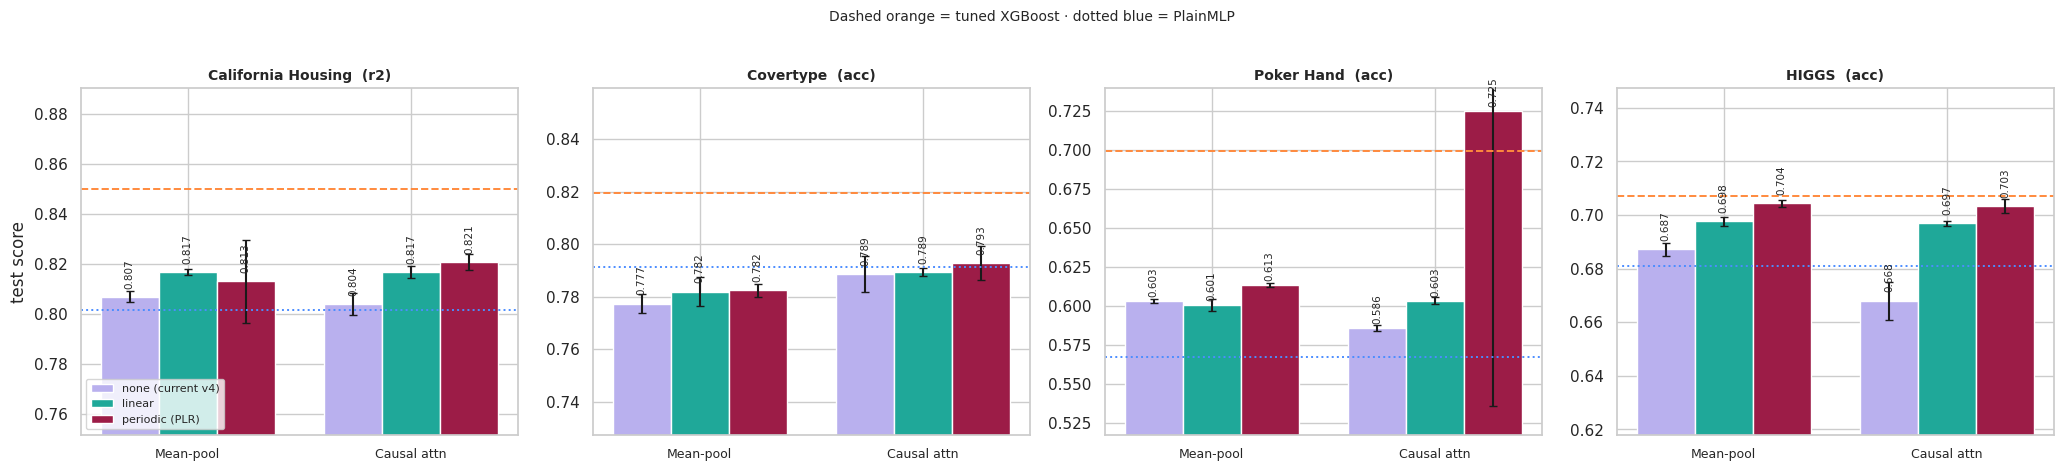

In [7]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.2 * len(DATASETS), 4.6))
for ax, name in zip(np.atleast_1d(axes), DATASETS):
    xs = np.arange(len(AGGREGATORS)); w = 0.26
    for i, mode in enumerate(MODES):
        vals = [tab.loc[(name, a), mode] for a in AGGREGATORS]
        errs = [sd.loc[(name, a), mode] for a in AGGREGATORS]
        ax.bar(xs + (i - 1) * w, vals, w, yerr=errs, capsize=3, color=COLOR[mode],
               label=MODE_LABEL[mode], edgecolor="white")
        for x, v in zip(xs + (i - 1) * w, vals):
            ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=7.5, rotation=90)
    ax.axhline(XGB[name].mean(), color=COLOR["XGBoost"], ls="--", lw=1.4)
    ax.axhline(tab.loc[(name, "PlainMLP"), "none"], color=COLOR["PlainMLP"], ls=":", lw=1.4)
    ax.set_xticks(xs); ax.set_xticklabels([AGG_LABEL[a] for a in AGGREGATORS], fontsize=9)
    lo = min(min(tab.loc[(name, a), m] for a in AGGREGATORS for m in MODES),
             tab.loc[(name, "PlainMLP"), "none"])
    ax.set_ylim(lo - 0.05, max(XGB[name].mean(), tab.loc[(name, AGGREGATORS[0]), "periodic"]) + 0.04)
    ax.set_title(f"{DS_LABEL[name]}  ({METRIC[name]})", fontweight="bold", fontsize=10)
axes[0].set_ylabel("test score"); axes[0].legend(fontsize=8, loc="lower left")
plt.suptitle("Dashed orange = tuned XGBoost · dotted blue = PlainMLP", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

### 5.1 Does the embedding help? (paired by seed)

Each seed trains every arm on the same split with the same batch order, so differences can be compared seed by
seed. `periodic − none` is the question; `linear − none` says how much of it comes from per-feature processing alone.

In [8]:
rows = []
for name in DATASETS:
    for agg in AGGREGATORS:
        base = main[(main.dataset == name) & (main.aggregator == agg) & (main["mode"] == "none")].set_index("seed")["score"]
        for mode in ("linear", "periodic"):
            other = main[(main.dataset == name) & (main.aggregator == agg) & (main["mode"] == mode)].set_index("seed")["score"]
            d = (other - base).values
            t, p = stats.ttest_rel(other.values, base.values)
            rows.append({"dataset": DS_LABEL[name], "aggregator": AGG_LABEL[agg], "change": f"{mode} − none",
                         "mean Δ": d.mean(), "wins": f"{int((d > 0).sum())}/{len(d)}", "p": p,
                         "verdict": ("better" if p < 0.05 and d.mean() > 0 else
                                     "worse" if p < 0.05 and d.mean() < 0 else "within noise")})
DELTA = pd.DataFrame(rows).set_index(["dataset", "aggregator", "change"])
show(DELTA, {"mean Δ": "{:+.4f}", "p": "{:.3f}"},
     style=lambda s: s.map(lambda v: {"better": "background-color:#d8f5e3", "worse": "background-color:#fbdada"}.get(v, ""),
                           subset=["verdict"]))

mean Δ wins       p  \
dataset            aggregator  change                                 
California Housing Mean-pool   linear − none    0.0097  3/3  0.0243   
                               periodic − none  0.0061  2/3  0.6012   
                   Causal attn linear − none    0.0128  3/3  0.0798   
                               periodic − none  0.0167  3/3  0.0564   
Covertype          Mean-pool   linear − none    0.0046  2/3  0.2178   
                               periodic − none  0.0051  3/3  0.0691   
                   Causal attn linear − none    0.0007  1/3  0.8855   
                               periodic − none  0.0040  2/3  0.5901   
Poker Hand         Mean-pool   linear − none   -0.0027  1/3  0.3831   
                               periodic − none  0.0099  3/3  0.0173   
                   Causal attn linear − none    0.0174  3/3  0.0004   
                               periodic − none  0.1390  3/3  0.3272   
HIGGS              Mean-pool   linear − none    0.0104  3/3  0.0016   
                               periodic − none  0.0172  3/3  0.0149   
                   Causal attn linear − none    0.0289  3/3  0.0230   
                               periodic − none  0.0353  3/3  0.0195   

                                                     verdict  
dataset            aggregator  change                         
California Housing Mean-pool   linear − none          better  
                               periodic − none  within noise  
                   Causal attn linear − none    within noise  
                               periodic − none  within noise  
Covertype          Mean-pool   linear − none    within noise  
                               periodic − none  within noise  
                   Causal attn linear − none    within noise  
                               periodic − none  within noise  
Poker Hand         Mean-pool   linear − none    within noise  
                               periodic − none        better  
                   Causal attn linear − none          better  
                               periodic − none  within noise  
HIGGS              Mean-pool   linear − none          better  
                               periodic − none        better  
                   Causal attn linear − none          better  
                               periodic − none        better

## 6. Mechanism check — is the model finally using the feature axes?

The diagnosis was rotation invariance. If per-feature embeddings fixed it, rotating the features should now **hurt**
the embedded model, while the un-embedded model should stay flat (as in notebook 04). A drop here is the good outcome:
it means the model is reading individual features rather than arbitrary mixtures of them.

upright  rotated  Δ from rotation  \
dataset            embedding                                              
California Housing none (current v4)   0.8040   0.7898          -0.0142   
                   periodic (PLR)      0.8207   0.7726          -0.0481   
Covertype          none (current v4)   0.7887   0.7829          -0.0058   
                   periodic (PLR)      0.7927   0.7709          -0.0218   
Poker Hand         none (current v4)   0.5860   0.5700          -0.0160   
                   periodic (PLR)      0.7250   0.5194          -0.2056   
HIGGS              none (current v4)   0.6680   0.6569          -0.0111   
                   periodic (PLR)      0.7033   0.6168          -0.0865   

                                     hurt on every seed  
dataset            embedding                             
California Housing none (current v4)                yes  
                   periodic (PLR)                   yes  
Covertype          none (current v4)                 no  
                   periodic (PLR)                   yes  
Poker Hand         none (current v4)                yes  
                   periodic (PLR)                   yes  
HIGGS              none (current v4)                yes  
                   periodic (PLR)                   yes

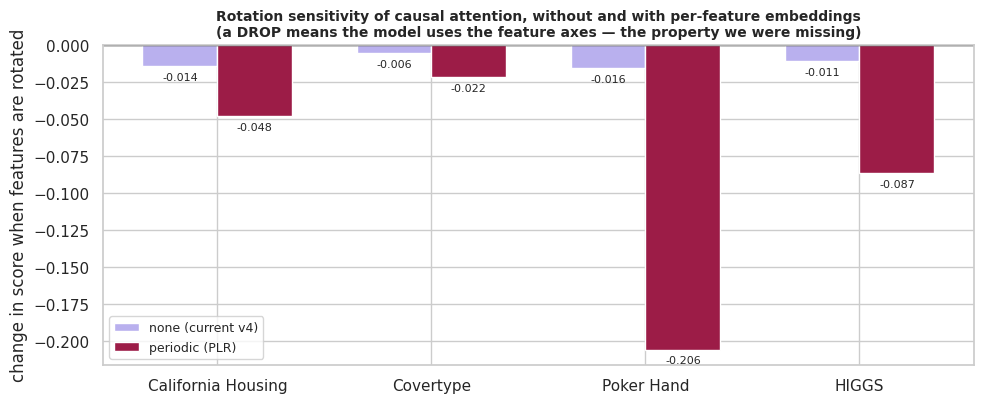

In [9]:
rows = []
for name in DATASETS:
    for mode in ("none", "periodic"):
        up = main[(main.dataset == name) & (main.aggregator == "causal") & (main["mode"] == mode)].set_index("seed")["score"]
        rot = R[(R.rotated) & (R.dataset == name) & (R["mode"] == mode)].set_index("seed")["score"]
        d = (rot - up).values
        rows.append({"dataset": DS_LABEL[name], "embedding": MODE_LABEL[mode],
                     "upright": up.mean(), "rotated": rot.mean(), "Δ from rotation": d.mean(),
                     "hurt on every seed": "yes" if (d < 0).all() else "no"})
ROT = pd.DataFrame(rows).set_index(["dataset", "embedding"])
show(ROT, {"upright": "{:.4f}", "rotated": "{:.4f}", "Δ from rotation": "{:+.4f}"})

fig, ax = plt.subplots(figsize=(10, 4.2))
xs = np.arange(len(DATASETS)); w = 0.35
for i, mode in enumerate(("none", "periodic")):
    vals = [ROT.loc[(DS_LABEL[n], MODE_LABEL[mode]), "Δ from rotation"] for n in DATASETS]
    ax.bar(xs + (i - 0.5) * w, vals, w, color=COLOR[mode], label=MODE_LABEL[mode], edgecolor="white")
    for x, v in zip(xs + (i - 0.5) * w, vals):
        ax.text(x, v - 0.004 if v < 0 else v + 0.002, f"{v:+.3f}", ha="center", fontsize=8,
                va="top" if v < 0 else "bottom")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(xs); ax.set_xticklabels([DS_LABEL[n] for n in DATASETS])
ax.set_ylabel("change in score when features are rotated")
ax.set_title("Rotation sensitivity of causal attention, without and with per-feature embeddings\n"
             "(a DROP means the model uses the feature axes — the property we were missing)",
             fontweight="bold", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 7. Findings

*(Computed from the runs above.)*

In [10]:
sep = "=" * 96
print(sep); print("FINDINGS — per-feature embeddings on four datasets"); print(sep)

print("\n1. Does the periodic embedding help? (paired over seeds, per dataset)")
wins = 0
for name in DATASETS:
    parts = []
    for agg in AGGREGATORS:
        r = DELTA.loc[(DS_LABEL[name], AGG_LABEL[agg], "periodic − none")]
        parts.append(f"{AGG_LABEL[agg]} {r['mean Δ']:+.4f} ({r['verdict']})")
        wins += r["verdict"] == "better"
    print(f"   {DS_LABEL[name]:20s} " + " | ".join(parts))
print(f"   -> improves in {wins}/{len(DATASETS)*len(AGGREGATORS)} dataset-aggregator combinations")

print("\n2. Is the periodic part needed, or is per-feature processing enough?")
for name in DATASETS:
    parts = []
    for agg in AGGREGATORS:
        lin = DELTA.loc[(DS_LABEL[name], AGG_LABEL[agg], "linear − none"), "mean Δ"]
        per = DELTA.loc[(DS_LABEL[name], AGG_LABEL[agg], "periodic − none"), "mean Δ"]
        parts.append(f"{AGG_LABEL[agg]}: linear {lin:+.4f} vs periodic {per:+.4f}")
    print(f"   {DS_LABEL[name]:20s} " + " | ".join(parts))

print("\n3. Mechanism: did the model become sensitive to rotation (i.e. start using the axes)?")
for name in DATASETS:
    n = ROT.loc[(DS_LABEL[name], MODE_LABEL["none"]), "Δ from rotation"]
    p = ROT.loc[(DS_LABEL[name], MODE_LABEL["periodic"]), "Δ from rotation"]
    verdict = "yes — embeddings made it axis-aware" if p < n - 0.005 else "no change in axis-awareness"
    print(f"   {DS_LABEL[name]:20s} none {n:+.4f} -> periodic {p:+.4f}   {verdict}")

print("\n4. Standing against the references (best embedded arm vs XGBoost and PlainMLP)")
for name in DATASETS:
    best_mode, best_agg, best = None, None, -np.inf
    for agg in AGGREGATORS:
        for mode in MODES:
            v = tab.loc[(name, agg), mode]
            if v > best: best, best_mode, best_agg = v, mode, agg
    mlp = tab.loc[(name, "PlainMLP"), "none"]
    print(f"   {DS_LABEL[name]:20s} best ours {best:.4f} ({AGG_LABEL[best_agg]}, {MODE_LABEL[best_mode]}) | "
          f"PlainMLP {mlp:.4f} ({best - mlp:+.4f}) | XGBoost {XGB[name].mean():.4f} ({best - XGB[name].mean():+.4f})")
print("\n" + sep)

FINDINGS — per-feature embeddings on four datasets

1. Does the periodic embedding help? (paired over seeds, per dataset)
   California Housing   Mean-pool +0.0061 (within noise) | Causal attn +0.0167 (within noise)
   Covertype            Mean-pool +0.0051 (within noise) | Causal attn +0.0040 (within noise)
   Poker Hand           Mean-pool +0.0099 (better) | Causal attn +0.1390 (within noise)
   HIGGS                Mean-pool +0.0171 (better) | Causal attn +0.0353 (better)
   -> improves in 3/8 dataset-aggregator combinations

2. Is the periodic part needed, or is per-feature processing enough?
   California Housing   Mean-pool: linear +0.0097 vs periodic +0.0061 | Causal attn: linear +0.0128 vs periodic +0.0167
   Covertype            Mean-pool: linear +0.0046 vs periodic +0.0051 | Causal attn: linear +0.0007 vs periodic +0.0040
   Poker Hand           Mean-pool: linear -0.0027 vs periodic +0.0099 | Causal attn: linear +0.0174 vs periodic +0.1390
   HIGGS                Mean-pool: l

## 8. What comes next

* If the periodic embedding helps **and** makes the model rotation-sensitive, the diagnosis was right and the same
  idea should be tried on the larger published benchmarks, where MLP-PLR is a published reference point.
* If it helps but rotation sensitivity does not change, the gain is coming from somewhere else (extra capacity in the
  wider expert inputs), and the honest description changes.
* The remaining diagnosed weakness is robustness to uninformative features, whose fix is per-expert feature gates.